<h1 style="text-align:center;">Indoor and Outdoor Familiarity Mapping</h1>


*Author* : Gabriel Gattaux

*Date* :  May 2024

## Setup and Imports


In [1]:
import memory
import antcar_sim
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import imutils
import pandas as pd
import plotly
import plotly.graph_objs as go
from scipy.interpolate import griddata
from plotly.subplots import make_subplots
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import subprocess
from scipy.stats import mode,circmean, circvar, circstd
from scipy.sparse import csr_matrix, save_npz, load_npz
from datetime import datetime
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import font_manager

# %load_ext autoreload
# %autoreload 2


In [2]:
## Configure paths
src_out = "/results/figures/familiarity_mapping/"

# Create the directory if it doesn't exist
if not os.path.exists(src_out):
    os.makedirs(src_out)

VERBOSE = False


In [3]:
# Configure Fonts 

# Set Seaborn style and context
sns.set_style("ticks")
sns.set_context("notebook")

precision_ang=5

# Define a custom colormap (blue to yellow)
colors = ["#0044d2ff", "white", "#c88300ff"]  # Blue to white to green

n_bins = 50  # Discretize the colormap into 100 bins
cmap_name = 'blue_to_yellow'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)



## Functions

In [4]:
## Usefuls function to get size of subfolders and reading images
def get_subfolders(folder_path):
    subfolders = []
    for item in os.listdir(folder_path):
        item_path = os.path.join(folder_path, item)
        if os.path.isdir(item_path):
            subfolders.append(item)
    return subfolders

# Function to get the real size of an image file on disk
def get_real_file_size(image_path):
    if os.path.exists(image_path):
        return os.path.getsize(image_path)
    else:
        return None

# Function to get the size of a folder and its subdirectories
def get_folder_size(folder_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

def get_first_images_sub(image_processed_path,folder):

    # Define the subdirectories
    # subdirs = ['augmented', 'pns', 'kcs', 'processed']
    subdirs = get_subfolders(os.path.join(image_processed_path,folder))

    # Generate file paths for the first image in each directory
    first_image_paths = {}
    file_sizes = []
    subdir_sizes = []
    dir = []
    images_nbs = []

    for idx,subdir in enumerate(subdirs):
        subdir_path = os.path.join(image_processed_path, folder, subdir)
        files = os.listdir(subdir_path)
        image_files = [file for file in files if file.endswith('.png')]
        lenn = len(image_files)

        # print(lenn)
        if image_files:
            first_image_paths[subdir] = os.path.join(subdir_path, image_files[0])
            file_sizes.append(get_real_file_size(first_image_paths[subdir]))
            subdir_sizes.append(get_folder_size(subdir_path))
            dir.append(folder + '/'+subdir)
            images_nbs.append(lenn)

    # Load the first image of each category using OpenCV
    pn = cv2.imread(first_image_paths.get('pns'), cv2.IMREAD_GRAYSCALE) if 'pns' in first_image_paths else None
    if 'kcs' in first_image_paths:
        kcname = 'kcs'
    else:
        kcname = 'kcs1'
    kc = cv2.imread(first_image_paths.get(kcname), cv2.IMREAD_GRAYSCALE)

    proc = cv2.imread(first_image_paths.get('processed'), cv2.IMREAD_GRAYSCALE) if 'processed' in first_image_paths else None
    normal = cv2.imread(first_image_paths.get('augmented'), cv2.IMREAD_COLOR) if 'augmented' in first_image_paths else None
    normal = cv2.cvtColor(normal, cv2.COLOR_BGR2RGB)

    if pn is not None:
        pn = np.tile(pn, (1, 50))
    else:
        print("No image found for 'pns'")
    
    return pn,kc,proc,normal,np.array(file_sizes),np.array(subdir_sizes),np.array(dir),images_nbs


# Function to convert bytes to human-readable format (KB, MB, GB)
def convert_bytes_to_human_readable(size_in_bytes):
    for unit in ['bytes', 'KB', 'MB', 'GB']:
        if size_in_bytes < 1024.0:
            return f"{size_in_bytes:.2f} {unit}"
        size_in_bytes /= 1024.0

def process_binary_vector_memories(compressed_memory_list, output_file_path):
    """
    Converts binary vector memories to CSR format, saves to disk, calculates file size,
    loads the CSR matrix back, and converts it to a NumPy array.

    Parameters:
    compressed_memory_list (list of list or np.array): The binary vector memories.
    output_file_path (str): The path where the CSR matrix will be saved.

    Returns:
    tuple: A tuple containing the size of the file in bytes and the NumPy array.
    """
    # Convert binary vector memories to CSR format
    csr_binary_vector = csr_matrix(compressed_memory_list)

    # Save CSR matrix to a file
    save_npz(output_file_path, csr_binary_vector)

    # Calculate the size of the saved file
    size_memories = get_real_file_size(output_file_path)

    # Load CSR matrix from the saved file
    loaded_csr_matrix = load_npz(output_file_path)

    # Convert CSR matrix to NumPy array
    numpy_array = loaded_csr_matrix.toarray()

    return size_memories, numpy_array

# Longest Streak of 0s and 1s
def longest_streak(arr, value):
    max_streak = 0
    current_streak = 0
    for i in arr:
        if i == value:
            current_streak += 1
            max_streak = max(max_streak, current_streak)
        else:
            current_streak = 0
    return max_streak

def process_dataset(src_processed):
    ## Aquire the learning process dataset, the compressed mem and the traj train
    mapping_learning_AVM_line = pd.read_csv(src_processed+'mapping_learning.csv') 
    mapping_test_AVM_line = pd.read_csv(src_processed+'mapping_test.csv') 
    ## Change columns names according to the current XP
    mapping_learning_AVM_line_cols = ['img_index1','x_truth1','y_truth1','theta_truth1','unfa1_learning','kc_sat1',
                                    'img_index2','x_truth2','y_truth2','theta_truth2', 'unfa2_learning','kc_sat2']
    mapping_test_AVM_line_cols = ['img_index','x_truth','y_truth','theta_truth','unfa1', 'unfa2','XTE_truth','HE_truth']
    mapping_learning_AVM_line = mapping_learning_AVM_line.rename(columns=dict(zip(mapping_learning_AVM_line.columns, mapping_learning_AVM_line_cols)))
    mapping_test_AVM_line = mapping_test_AVM_line.rename(columns=dict(zip(mapping_test_AVM_line.columns, mapping_test_AVM_line_cols)))

    ## Extract intresting datas from the datasets
    ## Convert the data to numpy
    mapping_learning_AVM_line_np = mapping_learning_AVM_line.to_numpy()
    traj_train_1 = mapping_learning_AVM_line_np[:,0:4] # index, x, y , theta
    unfamiliarity_train_1 = mapping_learning_AVM_line_np[:,4]
    kc_saturation_train_1 = mapping_learning_AVM_line_np[:,5]
    traj_train_2 = mapping_learning_AVM_line_np[:,6:10] # index, x, y , theta
    unfamiliarity_train_2 = mapping_learning_AVM_line_np[:,10]
    kc_saturation_train_2 = mapping_learning_AVM_line_np[:,11]
    unfamiliarity_train = np.array([unfamiliarity_train_1,unfamiliarity_train_2]).T
    kc_saturation_train = np.array([kc_saturation_train_1,kc_saturation_train_2]).T
    ## Extract the base point (first x and y) and distances from it
    base_point_1 = traj_train_1[0,1:3]
    base_point_2 = traj_train_2[0,1:3]
    # Calculate distances from the base point to each point in the array during learning
    distances = np.array([np.sqrt(np.sum((traj_train_1[:,1:3] - base_point_1) ** 2, axis=1)),
                        np.sqrt(np.sum((traj_train_2[:,1:3] - base_point_2) ** 2, axis=1))]).T

    ## Transform to numpy arrays ; Extract the desired datas  mapping_test_AVM_line_np
    mapping_test_AVM_line_np = mapping_test_AVM_line.to_numpy()
    img_index_test = mapping_test_AVM_line_np[:,0]
    x_truth_test = mapping_test_AVM_line_np[:,1]
    y_truth_test = mapping_test_AVM_line_np[:,2]
    theta_truth_test = mapping_test_AVM_line_np[:,3]
    unfamiliarity_test_1 = mapping_test_AVM_line_np[:,4]
    unfamiliarity_test_2 = mapping_test_AVM_line_np[:,5]
    XTE_error_test = mapping_test_AVM_line_np[:,6]
    HE_error_test = mapping_test_AVM_line_np[:,7]
    ## Find unique (x, y) pairs
    xy_combined = x_truth_test + 1j * y_truth_test
    unique_xy, unique_indices = np.unique(xy_combined, return_index=True)
    x_unique = x_truth_test[unique_indices]
    y_unique = y_truth_test[unique_indices]
    ## Compute Difference, sum, max and relations between unfamilaities columns
    unfamiliarity_ini_dif_raw =  unfamiliarity_test_2- unfamiliarity_test_1 ## This look like angular speed
    unfamiliarity_ini_max_raw = np.maximum(unfamiliarity_test_1,unfamiliarity_test_2) ## This lokk like angular position
    ## Reshape unfamiliarities according to heading difference from the path
    unfamiliarity_ini1_index = unfamiliarity_test_1.reshape(-1, (360//precision_ang) +1)
    unfamiliarity_ini2_index = unfamiliarity_test_2.reshape(-1, (360//precision_ang) +1)
    unfamiliarity_ini_dif = unfamiliarity_ini_dif_raw.reshape(-1, (360//precision_ang) +1)
    unfamiliarity_ini_max = unfamiliarity_ini_max_raw.reshape(-1, (360//precision_ang) +1)
    ## Calculating the mean and the std of each observations
    m_unfa_1 = np.mean(unfamiliarity_ini1_index,axis=0) ; std_unfa_1 = np.std(unfamiliarity_ini1_index,axis=0)
    m_unfa_2 = np.mean(unfamiliarity_ini2_index,axis=0) ; std_unfa_2 = np.std(unfamiliarity_ini2_index,axis=0)
    m_unfa_dif = np.mean(unfamiliarity_ini_dif,axis=0) ; std_unfa_dif = np.std(unfamiliarity_ini_dif,axis=0)
    m_unfa_max = np.mean(unfamiliarity_ini_max,axis=0) ; std_unfa_max = np.std(unfamiliarity_ini_max,axis=0)

    ## Extract only the mapping datas on the learning path (i.e XTE or d == 0)
    mapping_on_learning_path_df = mapping_test_AVM_line[mapping_test_AVM_line['XTE_truth'] == 0]
    mapping_on_learning_path = mapping_on_learning_path_df.to_numpy()
    ## Extract desired states from the on-route mapping
    unfamiliarity_test_learningpath_1 = mapping_on_learning_path[:,4]
    unfamiliarity_test_learningpath_2 = mapping_on_learning_path[:,5]
    x_truth_test_learningpath = mapping_on_learning_path[:,1]
    y_truth_test_learningpath = mapping_on_learning_path[:,2]
    path_relativ_angle = mapping_on_learning_path[:,7]
    ## Compute Difference, sum, max and relations between unfamilaities on route columns
    unfamiliarity_onroute_dif_raw = unfamiliarity_test_learningpath_2 - unfamiliarity_test_learningpath_1## This look like angular speed
    unfamiliarity_onroute_max_raw = np.maximum(unfamiliarity_test_learningpath_1,unfamiliarity_test_learningpath_2) ## This lokk like angular position
    ## Reshape the familiarities to be on the same axe 'HE' or 'thetae' for each images (i.e position) on the path 
    unfamiliarity_onroute_1 = unfamiliarity_test_learningpath_1.reshape(-1, (360//precision_ang)+1)
    unfamiliarity_onroute_2 = unfamiliarity_test_learningpath_2.reshape(-1, (360//precision_ang)+1)
    unfamiliarity_onroute_dif = unfamiliarity_onroute_dif_raw.reshape(-1, (360//precision_ang) +1)
    unfamiliarity_onroute_max = unfamiliarity_onroute_max_raw.reshape(-1, (360//precision_ang) +1)
    thetae_ini = path_relativ_angle.reshape(-1, (360//precision_ang) +1)

    ## Compute the mean and std according to the 'HE' states for each images
    m_unfa_onroute_1 = np.mean(unfamiliarity_onroute_1,axis=0) ; std_unfa_onroute_1 = np.std(unfamiliarity_onroute_1,axis=0)
    m_unfa_onroute_2 = np.mean(unfamiliarity_onroute_2,axis=0) ; std_unfa_onroute_2 = np.std(unfamiliarity_onroute_2,axis=0)
    m_unfa_onroute_dif = np.mean(unfamiliarity_onroute_dif,axis=0) ; std_unfa_onroute_dif = np.std(unfamiliarity_onroute_dif,axis=0)
    m_unfa_onroute_max = np.mean(unfamiliarity_onroute_max,axis=0) ; std_unfa_onroute_max = np.std(unfamiliarity_onroute_max,axis=0)
    m_arg = np.arange(-180,(180+precision_ang),precision_ang)


    return {
        "XTE_error_test": XTE_error_test,
        "HE_error_test": HE_error_test,
        "unfamiliarity_ini_dif_raw": unfamiliarity_ini_dif_raw,
        "unfamiliarity_ini_max_raw": unfamiliarity_ini_max_raw,
        "m_unfa_onroute_dif": m_unfa_onroute_dif,
        "m_unfa_onroute_max": m_unfa_onroute_max,
        "std_unfa_onroute_dif": std_unfa_onroute_dif,
        "std_unfa_onroute_max": std_unfa_onroute_max,
        "m_arg": m_arg,
        "unfamiliarity_test_2":m_unfa_onroute_2,
        "unfamiliarity_test_1":m_unfa_onroute_1
        }


## Data Loading

In [5]:
des1 = "7ae1172d/"
des2 = '7ae1172d/'
## Here change the des1 and des2 name to two differents mapping name created with the train_test_mapping.py code
df = pd.read_csv("/results/mapping_parameters.csv", sep=",")  # Adjust separator if not tab-separated
result = df.iloc[0, -1].strip()  # Strip removes any extra spaces or newlines

IN = process_dataset('/results/mapping_' + str(result) + '/')
OUT = process_dataset('/results/mapping_' + str(result) + '/')


## Exploratory Data Analysis (EDA)

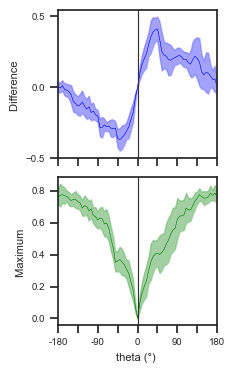

In [6]:
width_in_inches = 60 / 25.4
height_in_inches = 95 / 25.4

# # Create the figure with two polar subplots
fig, axes = plt.subplots(2,1, figsize=(width_in_inches, height_in_inches))

# Plot data for the first set
axes[0].plot(IN["m_arg"], IN["m_unfa_onroute_dif"], color='blue', label='$\lambda_1$',linewidth=0.3)
axes[0].fill_between(IN["m_arg"], IN["m_unfa_onroute_dif"] - IN["std_unfa_onroute_dif"], IN["m_unfa_onroute_dif"] + IN["std_unfa_onroute_dif"] , alpha=0.2, color="blue")
# Plot data for the second set
axes[0].plot(OUT["m_arg"], OUT["m_unfa_onroute_dif"], color='blue', label='$\lambda_2$',linewidth=0.3,linestyle='--')
axes[0].fill_between(OUT["m_arg"], OUT["m_unfa_onroute_dif"] - OUT["std_unfa_onroute_dif"], OUT["m_unfa_onroute_dif"] + OUT["std_unfa_onroute_dif"], alpha=0.2, color='blue',linestyle='--',linewidth=0.3)
axes[0].set_ylabel("Difference ")
axes[0].set_xlim([-180,180])
axes[0].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[0].set_xticklabels([])
axes[0].set_yticks([-0.5,0,0.5])

# Plot data for the first set
axes[1].plot(IN["m_arg"], IN["m_unfa_onroute_max"], color='green', label='$\lambda_1$',linewidth=0.3)
axes[1].fill_between(IN["m_arg"], IN["m_unfa_onroute_max"] - IN["std_unfa_onroute_max"], IN["m_unfa_onroute_max"] + IN["std_unfa_onroute_max"] , alpha=0.2, color='green')
# Plot data for the second set
axes[1].plot(OUT["m_arg"], OUT["m_unfa_onroute_max"], color='green', label='$\lambda_2$',linewidth=0.3,linestyle='--')
axes[1].fill_between(OUT["m_arg"], OUT["m_unfa_onroute_max"] - OUT["std_unfa_onroute_max"], OUT["m_unfa_onroute_max"] + OUT["std_unfa_onroute_max"], alpha=0.2, color='green',linestyle='--',linewidth=0.3)
axes[1].set_ylabel("Maximum ")
axes[1].set_xlim([-180,180])
axes[1].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[1].set_xticklabels([-180,'',-90,'',0,'',90,'',180])
axes[1].set_xlabel("theta (°) ")

inner_line_width_points = 0.30 / 25.4 * 72

axes[0].axvline(x=0, color='0.2', linestyle='-',linewidth = inner_line_width_points)
axes[1].axvline(x=0, color='0.2', linestyle='-',linewidth = inner_line_width_points)

plt.tight_layout()

fig.savefig(src_out+'max_dif_1.svg', format='svg')


/tmp/ipykernel_15612/480842738.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


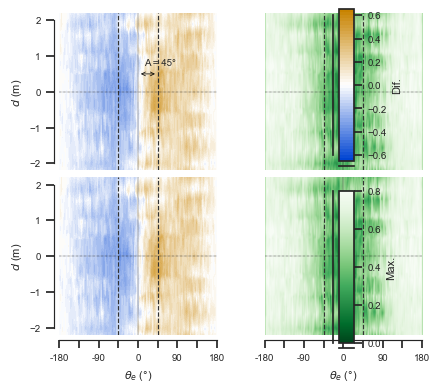

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Convert mm to inches
width_in_inches = 110 / 25.4
height_in_inches = 110 / 25.4
line_width_points = 0.2 / 25.4 * 72
inner_line_width_points = 0.30 / 25.4 * 72
little_width_points = 0.1 / 25.4 * 72
A_linewidth = 0.3 / 25.4 * 72

Y = np.linspace(-180, 180, 200)
X = np.linspace(-2.2, 2.2, 200)
theta, dist = np.meshgrid(Y, X)

# Create the figure with four polar subplots
fig, axes = plt.subplots(2,2, figsize=(width_in_inches, height_in_inches))

# Interpolate values onto the grid
zq_dif = griddata((IN["HE_error_test"], IN["XTE_error_test"]), IN["unfamiliarity_ini_dif_raw"], (theta, dist), method='linear',fill_value=0)
zq_max = griddata((IN["HE_error_test"], IN["XTE_error_test"]), IN["unfamiliarity_ini_max_raw"], (theta, dist), method='linear',fill_value=0.5)

# Interpolate values onto the grid
zq_dif_o = griddata((OUT["HE_error_test"], OUT["XTE_error_test"]), OUT["unfamiliarity_ini_dif_raw"], (theta, dist), method='linear',fill_value=0)
zq_max_o = griddata((OUT["HE_error_test"], OUT["XTE_error_test"]), OUT["unfamiliarity_ini_max_raw"], (theta, dist), method='linear',fill_value=0.5)


# Plot data for the third subplot
# contour3 = axes[0].contourf(theta, dist, zq_dif,levels=level3, cmap=custom_cmap, vmin=-0.6, vmax=0.6)
im1 = axes[0,0].imshow(zq_dif, cmap=custom_cmap, vmin=-0.65, vmax=0.65, interpolation='bicubic', aspect='auto', extent=(-180, 180, -2.2, 2.2))

# Plot data for the fourth subplot
im2 = axes[0,1].imshow(zq_max, cmap='Greens_r', vmin=0, vmax=0.8, interpolation='bicubic', aspect='auto', extent=(-180, 180, -2.2, 2.2))

im3 = axes[1,0].imshow(zq_dif_o, cmap=custom_cmap, vmin=-0.65, vmax=0.65, interpolation='bicubic', aspect='auto', extent=(-180, 180, -2.2, 2.2))

# Plot data for the fourth subplot
im4 = axes[1,1].imshow(zq_max_o, cmap='Greens_r', vmin=0, vmax=0.8, interpolation='bicubic', aspect='auto', extent=(-180, 180, -2.2, 2.2))


# Customize plots (e.g., grid lines, tick labels)
for ax in axes.flat:
    # ax.set_theta_offset(np.radians(90))
    for line in ax.yaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')
    for line in ax.xaxis.get_gridlines():
        line.set_linestyle('--')
        line.set_linewidth(inner_line_width_points)
        line.set_color('gray')

axes[0,0].set_xlim([-180,180])
axes[0,1].set_xlim([-180,180])

axes[0,0].set_ylim([-2.2,2.2])
axes[0,1].set_ylim([-2.2,2.2])
axes[0,0].spines["top"].set_linewidth(0)
axes[0,0].spines["bottom"].set_linewidth(0)
axes[0,0].spines["right"].set_linewidth(0)

axes[0,1].spines["top"].set_linewidth(0)
axes[0,1].spines["bottom"].set_linewidth(0)
axes[0,1].spines["right"].set_linewidth(0)
axes[0,1].spines["left"].set_linewidth(0)

axes[1,1].spines["left"].set_linewidth(0)

# axes[1].set_xticklabels([-175,180])
# axes[0].set_yticklabels([])
axes[0,0].set_xticks([])
axes[0,0].set_ylabel("$d$ (m)")
axes[1,0].set_ylabel("$d$ (m)")
axes[1,0].set_xlabel(r"$\theta_e$ (°)")
axes[1,1].set_xlabel(r"$\theta_e$ (°)")

axes[0,1].set_xticks([])
axes[0,1].set_yticks([])

axes[1,1].set_yticks([])

axes[0,1].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[0,1].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[0,0].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[0,0].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)

axes[1,1].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[1,1].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[1,0].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[1,0].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)

axes[1,0].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)
axes[1,1].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)
axes[0,0].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)
axes[0,1].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)

axes[0,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[0,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,1].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)
axes[1,0].axhline(y=0, color='0.1', linestyle='-.',linewidth = little_width_points)

# Add the double-headed arrow
axes[0,0].annotate(
    '', xy=(45, 0.5), xytext=(0, 0.5),
    arrowprops=dict(arrowstyle='<->', color='black', lw=0.5)
)

# Annotate with the letter "A"
axes[0,0].text(50, 0.75, 'A = 45°', ha='center')


axes[1,0].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[1,0].set_xticklabels([-180,'',-90,'',0,'',90,'',180])

axes[1,1].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[1,1].set_xticklabels([-180,'',-90,'',0,'',90,'',180])

cbar_dif = fig.colorbar(im1, ax=[axes[0, 0], axes[0, 1]], location='right', pad=0.5, aspect=10)
cbar_max = fig.colorbar(im2, ax=[axes[1,0], axes[1, 1]], location='right', pad=0.5, aspect=10)
cbar_max.set_label('Max.')
cbar_dif.set_label('Dif.')

# axes[1,0].set_box('equal')
axes[1,0].set_box_aspect(1)
axes[0,0].set_box_aspect(1)
axes[1,1].set_box_aspect(1)
axes[0,1].set_box_aspect(1)

# for ax in axes.flat:

axes[0,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['left'].set_linewidth(inner_line_width_points)
axes[1,0].spines['bottom'].set_linewidth(inner_line_width_points)
axes[1,1].spines['bottom'].set_linewidth(inner_line_width_points)

#     ax.spines['bottom'].set_linewidth(inner_line_width_points)
#     ax.spines['left'].set_linewidth(inner_line_width_points)
#     ax.spines['right'].set_linewidth(inner_line_width_points)
#     # Set any other properties here
#     sns.despine(ax=ax, offset=4, trim=True)  # Ensuring each subplot is despined individually


sns.despine(fig,offset=4,trim=True)
# axes[1].set_yticklabels([-2,2])

    # ax.spines['polar'].set_linewidth(line_width_points)
# axes[1,0].set_aspect(box=1)
plt.tight_layout()
plt.show()

fig.savefig(src_out+'mapping_d_theta.svg', format='svg')


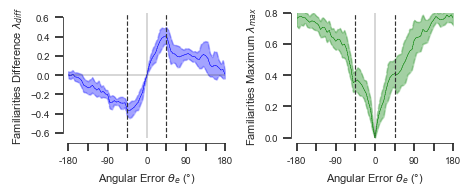

In [8]:


inner_line_width_points = 0.20 / 25.4 * 72
width_in_inches = 120 / 25.4
height_in_inches = 50 / 25.4

line_width_points = 0.2 / 25.4 * 72
little_width_points = 0.1 / 25.4 * 72
A_linewidth = 0.3 / 25.4 * 72


# Create the figure with two polar subplots
fig, axes = plt.subplots(1,2, figsize=(width_in_inches, height_in_inches))

# Plot data for the first set
axes[0].plot(IN["m_arg"], IN["m_unfa_onroute_dif"], color='blue', label='$\lambda_1$',linewidth=0.3)
axes[0].fill_between(IN["m_arg"], IN["m_unfa_onroute_dif"] - IN["std_unfa_onroute_dif"], IN["m_unfa_onroute_dif"] + IN["std_unfa_onroute_dif"] , alpha=0.2, color="blue")
# Plot data for the second set
axes[0].plot(OUT["m_arg"], OUT["m_unfa_onroute_dif"], color='blue', label='$\lambda_2$',linewidth=0.3,linestyle='--')
axes[0].fill_between(OUT["m_arg"], OUT["m_unfa_onroute_dif"] - OUT["std_unfa_onroute_dif"], OUT["m_unfa_onroute_dif"] + OUT["std_unfa_onroute_dif"], alpha=0.2, color='blue',linestyle='--')

# Plot data for the first set
axes[1].plot(IN["m_arg"], IN["m_unfa_onroute_max"], color='green', label='$\lambda_1$',linewidth=0.3,linestyle='-')
axes[1].fill_between(IN["m_arg"], IN["m_unfa_onroute_max"] - IN["std_unfa_onroute_max"], IN["m_unfa_onroute_max"] + IN["std_unfa_onroute_max"] , alpha=0.2, color='green',linestyle='-')
# Plot data for the second set
axes[1].plot(OUT["m_arg"], OUT["m_unfa_onroute_max"], color='green', label='$\lambda_2$',linewidth=0.3,linestyle='--')
axes[1].fill_between(OUT["m_arg"], OUT["m_unfa_onroute_max"] - OUT["std_unfa_onroute_max"], OUT["m_unfa_onroute_max"] + OUT["std_unfa_onroute_max"], alpha=0.2, color='green',linestyle='--')
fig.savefig(src_out+'max_dif_2.svg', format='svg')

axes[1].set_xlabel(r"Angular Error $\theta_e$ (°)")
axes[0].set_xlabel(r"Angular Error $\theta_e$ (°)")
axes[0].set_ylabel(r"Familiarities Difference $\lambda_{diff}$")
axes[1].set_ylabel(r"Familiarities Maximum $\lambda_{max}$")

axes[0].axhline(y=0, color='0.2', linestyle='-',linewidth = little_width_points)
axes[0].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)
axes[1].axvline(x=0, color='0.2', linestyle='-',linewidth = little_width_points)

axes[0].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[1].axvline(x=45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[0].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)
axes[1].axvline(x=-45, color='0.2', linestyle='--',linewidth = A_linewidth)

# axes[0].grid(True,color='0.92')
# axes[1].grid(True,color='0.92')
# axes[0].grid(True, alpha=0.3, which='both', zorder=0)
# axes[1].grid(True, alpha=0.3, which='both', zorder=0)

axes[0].set_xlim([-180,180])
axes[0].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[0].set_xticklabels([-180,'',-90,'',0,'',90,'',180])
axes[0].set_ylim([-0.65,0.65])

axes[1].set_xlim([-180,180])
axes[1].set_xticks([-180,-135,-90,-45,0,45,90,135,180])
axes[1].set_xticklabels([-180,'',-90,'',0,'',90,'',180])
axes[1].set_ylim([0,0.8])

# axes[0].text(-172, 0.5, 'd = 0', ha='left')


for ax in axes:
    ax.spines['top'].set_linewidth(inner_line_width_points)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)
    ax.spines['left'].set_linewidth(inner_line_width_points)
    ax.spines['right'].set_linewidth(inner_line_width_points)
    sns.despine(ax=ax, offset=4, trim=True)



plt.tight_layout()


fig.savefig(src_out+'max_dif_1.svg', format='svg')

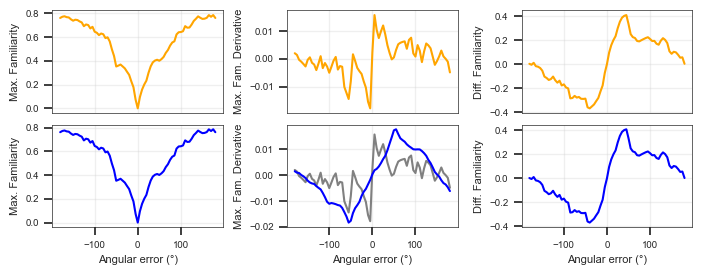

In [9]:
from scipy import signal
# Convert mm to inches
width_in_inches = 180 / 25.4
height_in_inches = 70 / 25.4

# Calculate the numerical derivative of lambda with respect to theta
d_lambda_d_theta = np.gradient(OUT["m_unfa_onroute_max"], OUT["m_arg"])
d_lambda_d_theta_in = np.gradient(IN["m_unfa_onroute_max"], IN["m_arg"])

d_lambda_d_theta_in_filt = 3*signal.savgol_filter(d_lambda_d_theta_in, window_length=21, polyorder=1, mode="nearest")
# Plot lambda(theta) and its derivative
fig, axes = plt.subplots(2, 3, figsize=(width_in_inches, height_in_inches))

# Plot lambda(theta)
axes[0, 0].plot(OUT["m_arg"], OUT["m_unfa_onroute_max"], label='lambda(theta)',color='orange')
axes[0, 0].set_ylabel('Max. Familiarity')
axes[0, 0].grid(True)

# Plot the derivative of lambda with respect to theta
axes[0, 1].plot(OUT["m_arg"], d_lambda_d_theta, label="d(lambda)/d(theta)", color='orange')
axes[0, 1].set_ylabel('Max. Fam. Derivative')
axes[0, 1].grid(True)

# Plot the difference in familiarity
axes[0, 2].plot(OUT["m_arg"], OUT["m_unfa_onroute_dif"], label="d(lambda)/d(theta)", color='orange')
axes[0, 2].set_ylabel('Diff. Familiarity')
axes[0, 2].grid(True)

# Plot lambda(theta) for IN data
axes[1, 0].plot(IN["m_arg"], IN["m_unfa_onroute_max"], label="lambda(theta)", color='blue')
axes[1, 0].set_xlabel('Angular error (°)')
axes[1, 0].set_ylabel('Max. Familiarity')
axes[1, 0].grid(True)

# Plot the derivative of lambda with respect to theta for IN data
axes[1, 1].plot(IN["m_arg"], d_lambda_d_theta_in, label="d(lambda)/d(theta)", color='gray')
axes[1, 1].plot(IN["m_arg"], d_lambda_d_theta_in_filt, label="Filtered d(lambda)/d(theta)", color='blue')
axes[1, 1].set_xlabel('Angular error (°)')
axes[1, 1].set_ylabel('Max. Fam. Derivative')
axes[1, 1].grid(True)

# Plot the difference in familiarity for IN data
axes[1, 2].plot(IN["m_arg"], IN["m_unfa_onroute_dif"], label="d(lambda)/d(theta)", color='blue')
axes[1, 2].set_xlabel('Angular error (°)')
axes[1, 2].set_ylabel('Diff. Familiarity')
axes[1, 2].grid(True)

# Adjust the spine line widths and apply despine
inner_line_width_points = 0.5
for ax in axes.flat:
    # Adjust spine line widths
    ax.spines['top'].set_linewidth(inner_line_width_points)
    ax.spines['bottom'].set_linewidth(inner_line_width_points)
    ax.spines['left'].set_linewidth(inner_line_width_points)
    ax.spines['right'].set_linewidth(inner_line_width_points)
    
    # Apply Seaborn despine with small offset
    ax.grid(True, alpha=0.3, which='both', zorder=0)

# Remove x-labels and x-tick labels for the first row plots
for ax in axes[0, :]:
    ax.set_xlabel('')  # Remove x-label
    ax.set_xticklabels([])  # Remove x-tick labels
    ax.tick_params(axis='x', length=0)  # Remove tick marks but keep grid

plt.tight_layout()
plt.show()

fig.savefig(src_out+'derivative_catchment_area.svg', format='svg')